SALES & DEMAND FORECASTING SYSTEM

Please select your 'Online Retail.xlsx' file.

Selected file:
C:/Users/DELL/Downloads/online+retail/Online Retail.xlsx

Dataset loaded successfully!
Number of rows: 541909
Number of columns: 8

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB
None

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Data cleaning completed.
Rows after cleaning: 530104
Total Sales: £10,666,684

,Date,Sales
0,2010-12-01,58960.79
1,2010-12-02,47748.38
2,2010-12-03,46943.71
3,2010-12-05,31774.95
4,2010-12-06,54830.46



Complete date range created.
Date range: 2010-12-01 to 2011-12-09

Feature engineering completed.
Final number of records: 346

Training records: 276
Testing records: 70

Training Random Forest model...
Model training completed!

MODEL PERFORMANCE
MAE  : 13100.03
RMSE : 23265.26
R²   : 0.4568

Actual vs Predicted:


,Date,Sales,PredictedSales
276,2011-10-01,0.00,258.130044
277,2011-10-02,11634.53,23484.819889
278,2011-10-03,66376.82,42008.873023
279,2011-10-04,48810.65,43489.816654
280,2011-10-05,75593.63,44881.379950
281,2011-10-06,62891.19,43199.924593
282,2011-10-07,53790.70,42769.178887
283,2011-10-08,0.00,176.189539
284,2011-10-09,12524.40,16031.122007
285,2011-10-10,48239.18,55332.489999


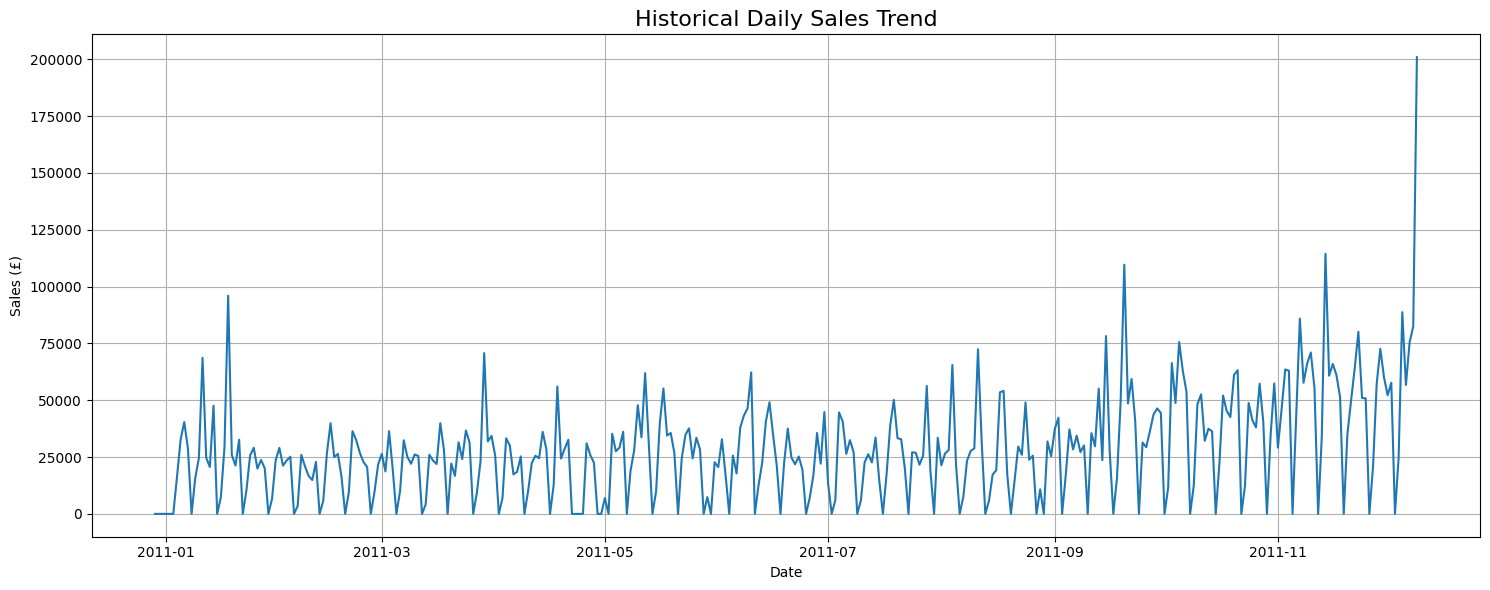

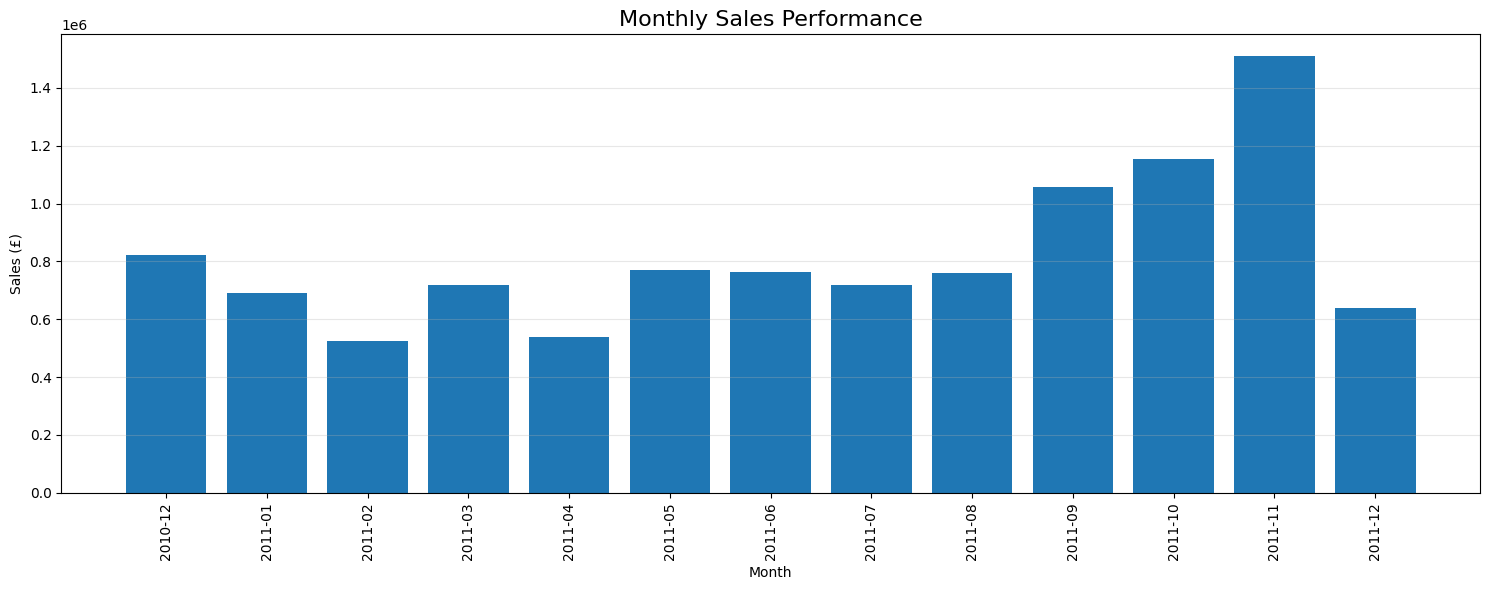

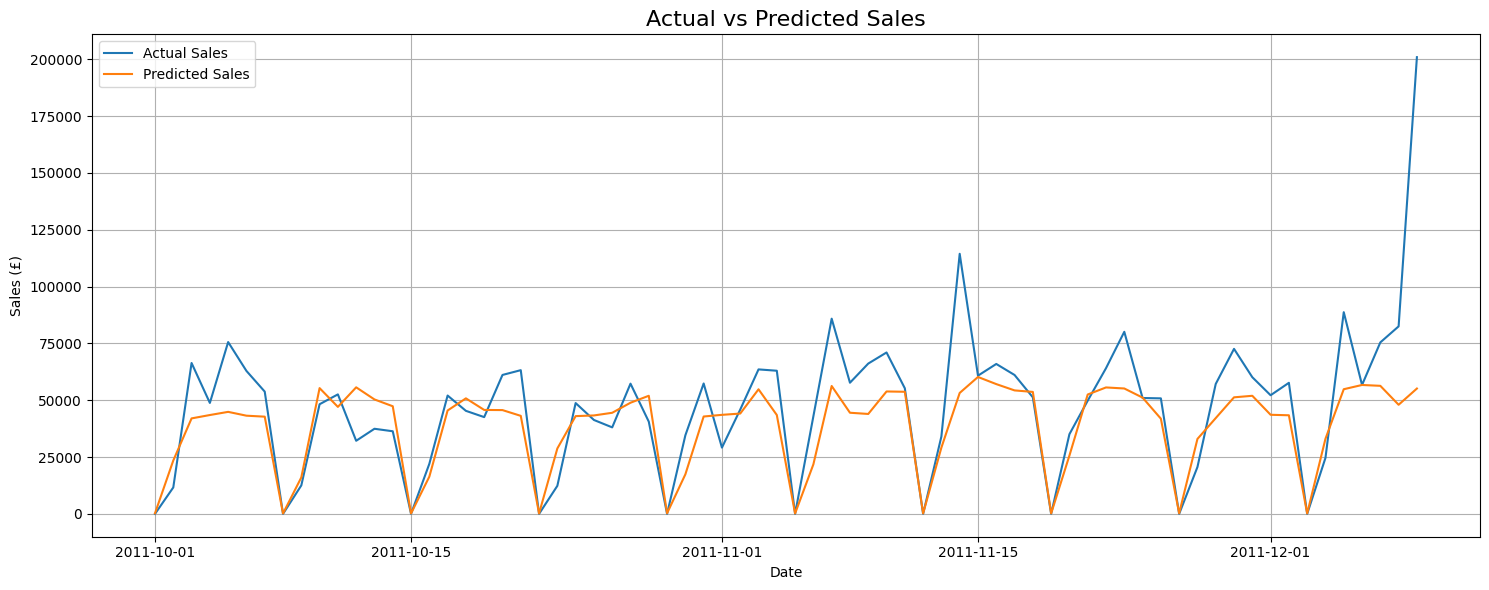

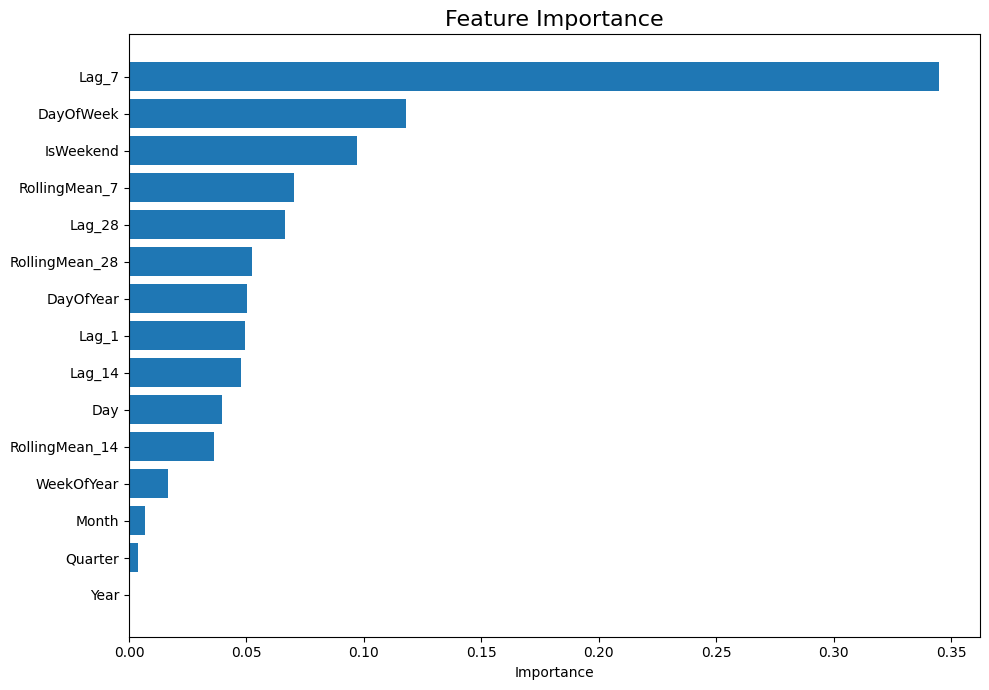


Generating forecast for next 30 days...

NEXT 30 DAYS SALES FORECAST


,Date,PredictedSales
0,2011-12-10,176.189539
1,2011-12-11,29421.106347
2,2011-12-12,53776.522437
3,2011-12-13,57507.400624
4,2011-12-14,56791.988953
5,2011-12-15,54358.438924
6,2011-12-16,54311.649365
7,2011-12-17,176.189539
8,2011-12-18,31152.327489
9,2011-12-19,48241.208190


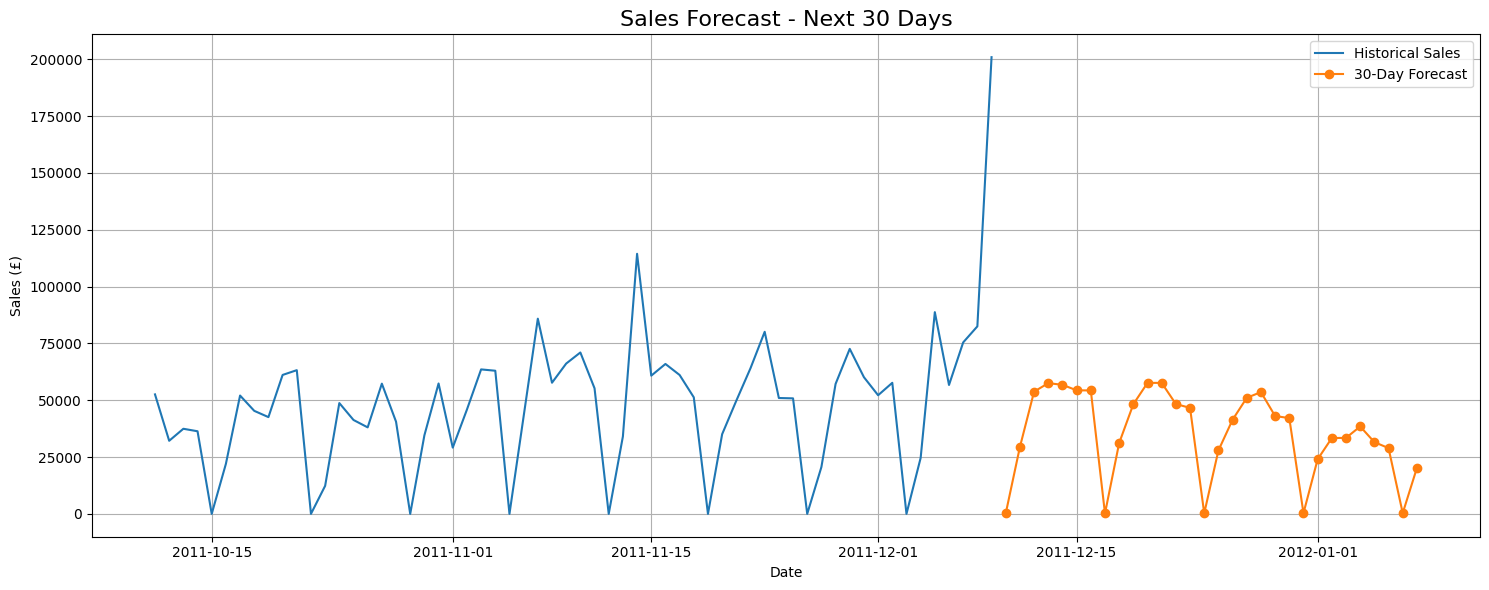


FORECAST SUMMARY
Forecast Period : 30 Days
Expected Total Sales : £1,066,215.70
Expected Average Daily Sales : £35,540.52
Highest Forecast Day : 2011-12-20 (£57,641.30)
Lowest Forecast Day : 2011-12-10 (£176.19)

30-day forecast saved as:
30_Day_Sales_Forecast.csv

Machine Learning model saved as:
sales_forecasting_model.pkl

BUSINESS INSIGHTS

1. SALES FORECASTING
   The model estimates expected sales for the next 30 days.

2. INVENTORY PLANNING
   Businesses can use the forecast to maintain appropriate
   inventory levels and reduce overstocking.

3. STAFFING
   Expected high-demand periods can help businesses plan
   employee schedules.

4. CASH FLOW
   Forecasted sales provide useful information for future
   revenue and cash-flow planning.

5. MARKETING
   Businesses can plan promotional campaigns around periods
   where demand is expected to increase.

6. DEMAND MANAGEMENT
   Historical sales patterns, recent sales and seasonal
   information are used by the model to estimate fu

In [3]:
# ============================================================
# SALES & DEMAND FORECASTING USING MACHINE LEARNING
# Dataset: UCI Online Retail Dataset
# Model: Random Forest Regression
# Forecast: Next 30 Days
# ============================================================

# ------------------------------------------------------------
# 1. INSTALL REQUIRED LIBRARIES
# ------------------------------------------------------------

!pip install -q pandas numpy matplotlib scikit-learn openpyxl joblib


# ------------------------------------------------------------
# 2. IMPORT LIBRARIES
# ------------------------------------------------------------

import os
import warnings
import tkinter as tk
from tkinter import filedialog

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

print("=" * 60)
print("SALES & DEMAND FORECASTING SYSTEM")
print("=" * 60)


# ------------------------------------------------------------
# 3. SELECT EXCEL FILE
# ------------------------------------------------------------

print("\nPlease select your 'Online Retail.xlsx' file.")

root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)

file_path = filedialog.askopenfilename(
    title="Select Online Retail Excel File",
    filetypes=[
        ("Excel Files", "*.xlsx *.xls"),
        ("All Files", "*.*")
    ]
)

root.destroy()

if not file_path:
    raise FileNotFoundError(
        "No file was selected. Please run the cell again and select Online Retail.xlsx."
    )

print("\nSelected file:")
print(file_path)


# ------------------------------------------------------------
# 4. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_excel(file_path)

print("\nDataset loaded successfully!")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 5. DISPLAY ORIGINAL DATA
# ------------------------------------------------------------

print("\nFirst 5 rows:")
display(df.head())


# ------------------------------------------------------------
# 6. CHECK DATASET INFORMATION
# ------------------------------------------------------------

print("\nDataset Information:")
print(df.info())


# ------------------------------------------------------------
# 7. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 8. DATA CLEANING
# ------------------------------------------------------------

# Remove rows with missing important values
df = df.dropna(
    subset=[
        "InvoiceNo",
        "StockCode",
        "Quantity",
        "InvoiceDate",
        "UnitPrice"
    ]
)

# Convert InvoiceNo to string
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

# Remove cancelled orders
df = df[
    ~df["InvoiceNo"].str.upper().str.startswith("C")
]

# Remove invalid quantities
df = df[df["Quantity"] > 0]

# Remove invalid prices
df = df[df["UnitPrice"] > 0]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

# Remove rows where date conversion failed
df = df.dropna(subset=["InvoiceDate"])

# Make sure Quantity and UnitPrice are numeric
df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["UnitPrice"] = pd.to_numeric(
    df["UnitPrice"],
    errors="coerce"
)

# Remove any remaining invalid values
df = df.dropna(
    subset=["Quantity", "UnitPrice"]
)


# ------------------------------------------------------------
# 9. CREATE SALES COLUMN
# ------------------------------------------------------------

df["Sales"] = df["Quantity"] * df["UnitPrice"]

print("\nData cleaning completed.")

print("Rows after cleaning:", len(df))

print(
    "Total Sales: £{:,.2f}".format(
        df["Sales"].sum()
    )
)


# ------------------------------------------------------------
# 10. CREATE DAILY SALES DATA
# ------------------------------------------------------------

df["Date"] = df["InvoiceDate"].dt.floor("D")

daily_sales = (
    df.groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales = daily_sales.sort_values("Date")

print("\nDaily sales dataset created.")

print("Number of days:", len(daily_sales))

display(daily_sales.head())


# ------------------------------------------------------------
# 11. FILL MISSING CALENDAR DAYS
# ------------------------------------------------------------

# Create complete daily date range
complete_dates = pd.date_range(
    start=daily_sales["Date"].min(),
    end=daily_sales["Date"].max(),
    freq="D"
)

daily_sales = (
    daily_sales
    .set_index("Date")
    .reindex(complete_dates)
    .fillna(0)
)

daily_sales.index.name = "Date"

daily_sales = daily_sales.reset_index()

print(
    "\nComplete date range created."
)

print(
    "Date range:",
    daily_sales["Date"].min().date(),
    "to",
    daily_sales["Date"].max().date()
)


# ------------------------------------------------------------
# 12. CREATE TIME-BASED FEATURES
# ------------------------------------------------------------

daily_sales["Year"] = daily_sales["Date"].dt.year
daily_sales["Month"] = daily_sales["Date"].dt.month
daily_sales["Day"] = daily_sales["Date"].dt.day
daily_sales["DayOfWeek"] = daily_sales["Date"].dt.dayofweek
daily_sales["WeekOfYear"] = (
    daily_sales["Date"].dt.isocalendar().week.astype(int)
)

daily_sales["Quarter"] = daily_sales["Date"].dt.quarter

daily_sales["DayOfYear"] = (
    daily_sales["Date"].dt.dayofyear
)

# Weekend feature
daily_sales["IsWeekend"] = (
    daily_sales["DayOfWeek"] >= 5
).astype(int)


# ------------------------------------------------------------
# 13. CREATE LAG FEATURES
# ------------------------------------------------------------

# Previous day sales
daily_sales["Lag_1"] = (
    daily_sales["Sales"].shift(1)
)

# Sales 7 days ago
daily_sales["Lag_7"] = (
    daily_sales["Sales"].shift(7)
)

# Sales 14 days ago
daily_sales["Lag_14"] = (
    daily_sales["Sales"].shift(14)
)

# Sales 28 days ago
daily_sales["Lag_28"] = (
    daily_sales["Sales"].shift(28)
)


# ------------------------------------------------------------
# 14. CREATE ROLLING FEATURES
# ------------------------------------------------------------

daily_sales["RollingMean_7"] = (
    daily_sales["Sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

daily_sales["RollingMean_14"] = (
    daily_sales["Sales"]
    .shift(1)
    .rolling(14)
    .mean()
)

daily_sales["RollingMean_28"] = (
    daily_sales["Sales"]
    .shift(1)
    .rolling(28)
    .mean()
)


# ------------------------------------------------------------
# 15. REMOVE ROWS WITH EMPTY LAG VALUES
# ------------------------------------------------------------

daily_sales = daily_sales.dropna()

daily_sales = daily_sales.reset_index(drop=True)

print(
    "\nFeature engineering completed."
)

print(
    "Final number of records:",
    len(daily_sales)
)


# ------------------------------------------------------------
# 16. SELECT MACHINE LEARNING FEATURES
# ------------------------------------------------------------

features = [
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "DayOfYear",
    "IsWeekend",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Lag_28",
    "RollingMean_7",
    "RollingMean_14",
    "RollingMean_28"
]

X = daily_sales[features]

y = daily_sales["Sales"]


# ------------------------------------------------------------
# 17. TIME-BASED TRAIN TEST SPLIT
# ------------------------------------------------------------

# IMPORTANT:
# We do NOT randomly shuffle time-series data.

split_index = int(
    len(daily_sales) * 0.80
)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))


# ------------------------------------------------------------
# 18. TRAIN RANDOM FOREST MODEL
# ------------------------------------------------------------

print("\nTraining Random Forest model...")

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("Model training completed!")


# ------------------------------------------------------------
# 19. TEST MODEL
# ------------------------------------------------------------

predictions = model.predict(X_test)


# ------------------------------------------------------------
# 20. MODEL EVALUATION
# ------------------------------------------------------------

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(
    "MAE  : {:.2f}".format(mae)
)

print(
    "RMSE : {:.2f}".format(rmse)
)

print(
    "R²   : {:.4f}".format(r2)
)


# ------------------------------------------------------------
# 21. CREATE ACTUAL VS PREDICTED DATAFRAME
# ------------------------------------------------------------

results = daily_sales.iloc[
    split_index:
].copy()

results["PredictedSales"] = predictions

print("\nActual vs Predicted:")
display(
    results[
        [
            "Date",
            "Sales",
            "PredictedSales"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 22. VISUALIZATION - HISTORICAL SALES TREND
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"]
)

plt.title(
    "Historical Daily Sales Trend",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Sales (£)")

plt.grid(True)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 23. VISUALIZATION - MONTHLY SALES
# ------------------------------------------------------------

monthly_sales = (
    df.groupby(
        df["InvoiceDate"].dt.to_period("M")
    )["Sales"]
    .sum()
)

monthly_sales.index = (
    monthly_sales.index.astype(str)
)

plt.figure(figsize=(15, 6))

plt.bar(
    monthly_sales.index,
    monthly_sales.values
)

plt.title(
    "Monthly Sales Performance",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Sales (£)")

plt.xticks(
    rotation=90
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 24. VISUALIZATION - ACTUAL VS PREDICTED
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    results["Date"],
    results["Sales"],
    label="Actual Sales"
)

plt.plot(
    results["Date"],
    results["PredictedSales"],
    label="Predicted Sales"
)

plt.title(
    "Actual vs Predicted Sales",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Sales (£)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 25. FEATURE IMPORTANCE
# ------------------------------------------------------------

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Feature Importance",
    fontsize=16
)

plt.xlabel("Importance")

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 26. FORECAST NEXT 30 DAYS
# ------------------------------------------------------------

forecast_days = 30

# Copy the latest historical data
forecast_data = daily_sales.copy()

future_predictions = []

last_date = forecast_data["Date"].max()

print(
    "\nGenerating forecast for next 30 days..."
)

for i in range(forecast_days):

    next_date = (
        last_date +
        pd.Timedelta(days=1)
    )

    # Get historical sales values
    sales_values = (
        forecast_data["Sales"]
        .values
    )

    # Make sure enough historical values exist
    if len(sales_values) < 28:
        raise ValueError(
            "Not enough historical data to create lag features."
        )

    # Lag values
    lag_1 = sales_values[-1]
    lag_7 = sales_values[-7]
    lag_14 = sales_values[-14]
    lag_28 = sales_values[-28]

    # Rolling averages
    rolling_7 = np.mean(
        sales_values[-7:]
    )

    rolling_14 = np.mean(
        sales_values[-14:]
    )

    rolling_28 = np.mean(
        sales_values[-28:]
    )

    # Date features
    year = next_date.year
    month = next_date.month
    day = next_date.day
    day_of_week = next_date.dayofweek
    week_of_year = next_date.isocalendar().week
    quarter = next_date.quarter
    day_of_year = next_date.dayofyear
    is_weekend = int(
        day_of_week >= 5
    )

    # Create feature row
    future_features = pd.DataFrame({
        "Year": [year],
        "Month": [month],
        "Day": [day],
        "DayOfWeek": [day_of_week],
        "WeekOfYear": [int(week_of_year)],
        "Quarter": [quarter],
        "DayOfYear": [day_of_year],
        "IsWeekend": [is_weekend],
        "Lag_1": [lag_1],
        "Lag_7": [lag_7],
        "Lag_14": [lag_14],
        "Lag_28": [lag_28],
        "RollingMean_7": [rolling_7],
        "RollingMean_14": [rolling_14],
        "RollingMean_28": [rolling_28]
    })

    # Predict next day
    next_prediction = model.predict(
        future_features[features]
    )[0]

    # Prevent negative sales
    next_prediction = max(
        0,
        next_prediction
    )

    future_predictions.append(
        next_prediction
    )

    # Add predicted day to forecasting data
    new_row = pd.DataFrame({
        "Date": [next_date],
        "Sales": [next_prediction]
    })

    forecast_data = pd.concat(
        [
            forecast_data[["Date", "Sales"]],
            new_row
        ],
        ignore_index=True
    )

    last_date = next_date


# ------------------------------------------------------------
# 27. CREATE FUTURE FORECAST TABLE
# ------------------------------------------------------------

future_forecast = pd.DataFrame({
    "Date": pd.date_range(
        start=daily_sales["Date"].max()
        + pd.Timedelta(days=1),
        periods=forecast_days
    ),
    "PredictedSales": future_predictions
})

print("\n" + "=" * 60)
print("NEXT 30 DAYS SALES FORECAST")
print("=" * 60)

display(future_forecast)


# ------------------------------------------------------------
# 28. FORECAST VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

# Last 60 historical days
recent_history = daily_sales.tail(60)

plt.plot(
    recent_history["Date"],
    recent_history["Sales"],
    label="Historical Sales"
)

plt.plot(
    future_forecast["Date"],
    future_forecast["PredictedSales"],
    marker="o",
    label="30-Day Forecast"
)

plt.title(
    "Sales Forecast - Next 30 Days",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Sales (£)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 29. FORECAST SUMMARY
# ------------------------------------------------------------

total_forecast = (
    future_forecast["PredictedSales"]
    .sum()
)

average_forecast = (
    future_forecast["PredictedSales"]
    .mean()
)

highest_day = (
    future_forecast.loc[
        future_forecast["PredictedSales"].idxmax()
    ]
)

lowest_day = (
    future_forecast.loc[
        future_forecast["PredictedSales"].idxmin()
    ]
)

print("\n" + "=" * 60)
print("FORECAST SUMMARY")
print("=" * 60)

print(
    "Forecast Period : 30 Days"
)

print(
    "Expected Total Sales : £{:,.2f}".format(
        total_forecast
    )
)

print(
    "Expected Average Daily Sales : £{:,.2f}".format(
        average_forecast
    )
)

print(
    "Highest Forecast Day : {} (£{:,.2f})".format(
        highest_day["Date"].date(),
        highest_day["PredictedSales"]
    )
)

print(
    "Lowest Forecast Day : {} (£{:,.2f})".format(
        lowest_day["Date"].date(),
        lowest_day["PredictedSales"]
    )
)


# ------------------------------------------------------------
# 30. SAVE FORECAST TO CSV
# ------------------------------------------------------------

future_forecast.to_csv(
    "30_Day_Sales_Forecast.csv",
    index=False
)

print(
    "\n30-day forecast saved as:"
)

print(
    "30_Day_Sales_Forecast.csv"
)


# ------------------------------------------------------------
# 31. SAVE MODEL
# ------------------------------------------------------------

joblib.dump(
    model,
    "sales_forecasting_model.pkl"
)

print(
    "\nMachine Learning model saved as:"
)

print(
    "sales_forecasting_model.pkl"
)


# ------------------------------------------------------------
# 32. BUSINESS INSIGHTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

print("""
1. SALES FORECASTING
   The model estimates expected sales for the next 30 days.

2. INVENTORY PLANNING
   Businesses can use the forecast to maintain appropriate
   inventory levels and reduce overstocking.

3. STAFFING
   Expected high-demand periods can help businesses plan
   employee schedules.

4. CASH FLOW
   Forecasted sales provide useful information for future
   revenue and cash-flow planning.

5. MARKETING
   Businesses can plan promotional campaigns around periods
   where demand is expected to increase.

6. DEMAND MANAGEMENT
   Historical sales patterns, recent sales and seasonal
   information are used by the model to estimate future demand.

7. BUSINESS DECISION MAKING
   Forecasting allows managers to make decisions using
   historical data instead of relying only on assumptions.
""")


# ------------------------------------------------------------
# 33. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)

print("""
Files generated:
1. sales_forecasting_model.pkl
2. 30_Day_Sales_Forecast.csv

The notebook contains:
✓ Data cleaning
✓ Missing-value handling
✓ Cancelled-order removal
✓ Sales calculation
✓ Daily sales aggregation
✓ Time-based features
✓ Lag features
✓ Rolling-average features
✓ Random Forest forecasting
✓ MAE evaluation
✓ RMSE evaluation
✓ R² evaluation
✓ Historical sales visualization
✓ Monthly sales visualization
✓ Actual vs predicted visualization
✓ Feature importance visualization
✓ 30-day future forecast
✓ Business insights
""")

print(
    "=" * 80
)

print(
    "PROJECT COMPLETED SUCCESSFULLY!"
)

print(
    "=" * 80
)